<div align="center">

![Course](https://img.shields.io/badge/Course-Advanced%20Data%20Science-blue?style=for-the-badge&logo=python&logoColor=white)
![Code](https://img.shields.io/badge/Code-125M1H031-informational?style=for-the-badge)
![Assignment](https://img.shields.io/badge/Formative%20Assessment-01-success?style=for-the-badge)

---

# Advanced Data Science
## Formative Assessment - 01
### Feature Engineering on California Housing Dataset

---
<br>

| Field | Details |
|---|---|
| **Academic Year** | **2026-2027** |
| **Class / Division** | **SYMCA (Semester-I)** |
| **PRN** | **125M1H031** |
| **Student Name** | **Shahid Momin** |
| **Submission Date** | **02-09-2026** |

</div>

## Introduction

Feature engineering is the process of creating new variables from existing 
data to reveal patterns that raw columns don't show clearly. In this 
activity, the **California Housing dataset** is used, which contains 
housing details like median income, house age, rooms, occupancy, and 
location for California block groups, with the target variable 
**MedHouseVal** representing median house value.

The objective is to create new engineered features, train a regression 
model before and after adding them, and compare R² scores to see whether 
feature engineering improves the model's predictions.

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

### Step 1: Load dataset


In [2]:
data = fetch_california_housing(as_frame=True)
df = data.frame
print(df.head())
print(df.columns)


   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='str')


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [6]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [7]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### Data Visualization 

In [25]:
df.corr()['MedHouseVal'].sort_values(ascending=False)

MedHouseVal               1.000000
MedInc                    0.688075
RoomsPerHousehold         0.209482
AveRooms                  0.151948
HouseAge                  0.105623
PopulationPerHousehold    0.065843
AveOccup                 -0.023737
Population               -0.024650
Longitude                -0.045967
AveBedrms                -0.046701
Latitude                 -0.144160
BedroomsPerRoom          -0.255624
Name: MedHouseVal, dtype: float64

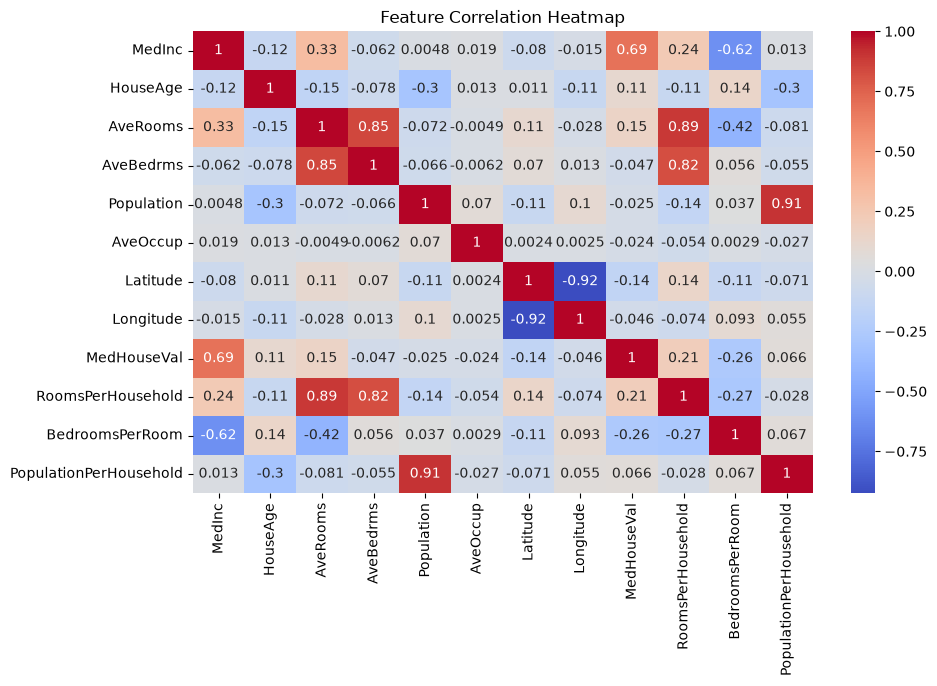

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Show correlation between all features as a heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

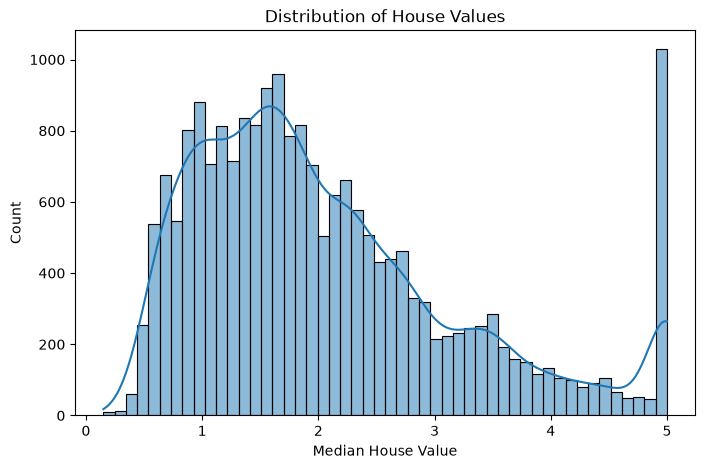

In [27]:
plt.figure(figsize=(8,5))
sns.histplot(df['MedHouseVal'], bins=50, kde=True)
plt.title("Distribution of House Values")
plt.xlabel("Median House Value")
plt.show()

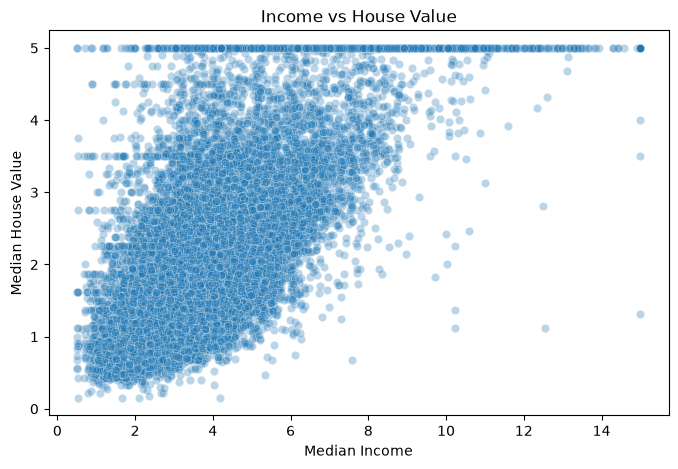

In [28]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['MedInc'], y=df['MedHouseVal'], alpha=0.3)
plt.title("Income vs House Value")
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.show()

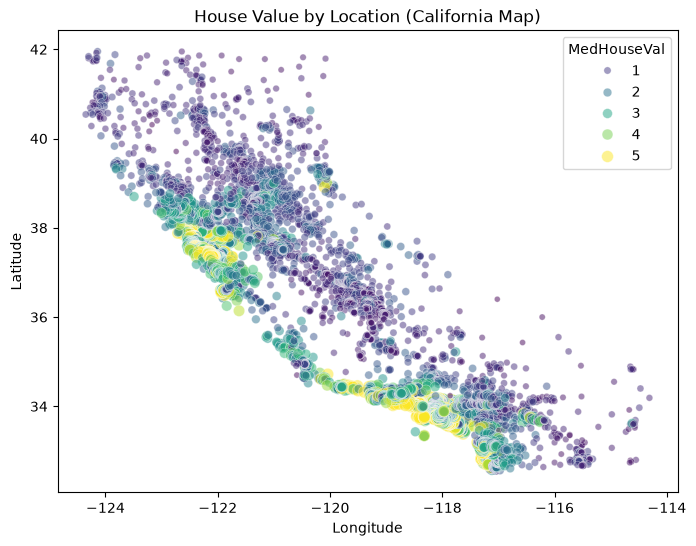

In [29]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=df['Longitude'], y=df['Latitude'], hue=df['MedHouseVal'],
                 palette='viridis', alpha=0.5, size=df['MedHouseVal'])
plt.title("House Value by Location (California Map)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

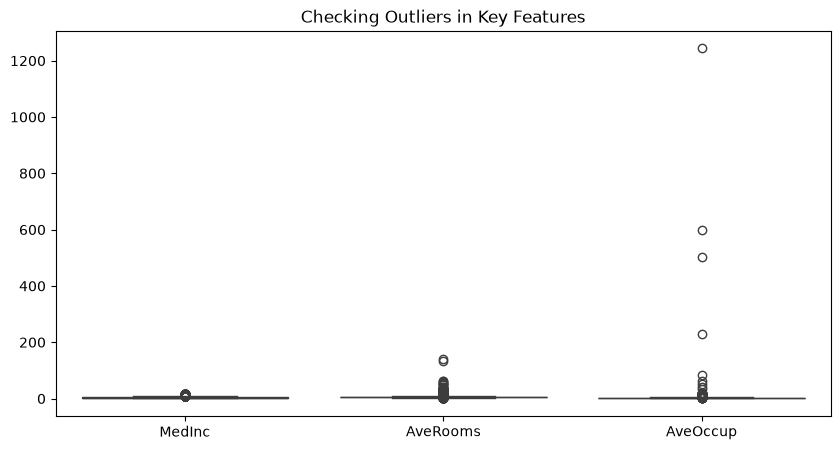

In [30]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df[['MedInc', 'AveRooms', 'AveOccup']])
plt.title("Checking Outliers in Key Features")
plt.show()


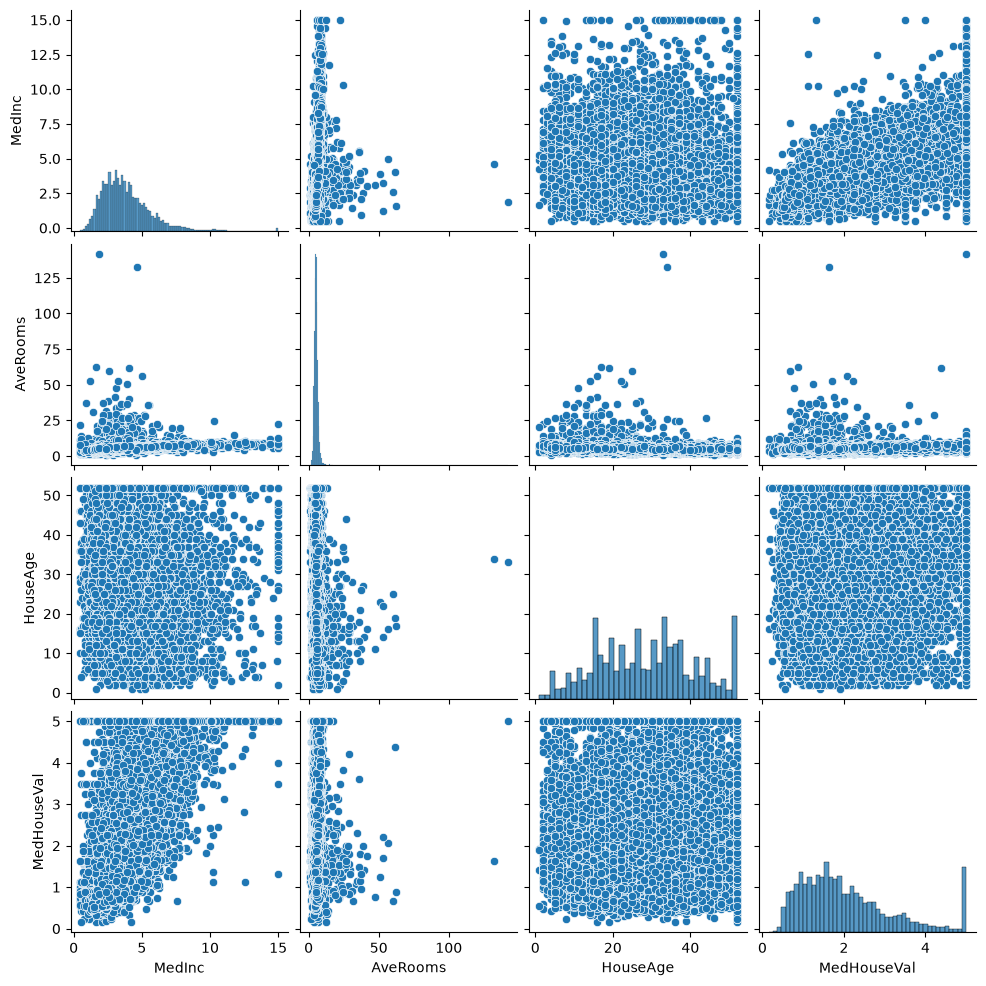

In [32]:
sns.pairplot(df[['MedInc', 'AveRooms', 'HouseAge', 'MedHouseVal']])
plt.show()

### Step 2: Baseline model (WITHOUT engineered features)


In [11]:

X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=12
)

model_before = LinearRegression()
model_before.fit(X_train, y_train)
pred_before = model_before.predict(X_test)
r2_before = r2_score(y_test, pred_before)

print("R squared WITHOUT engineered features:", r2_before)

R squared WITHOUT engineered features: 0.6156635727330055


In [12]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


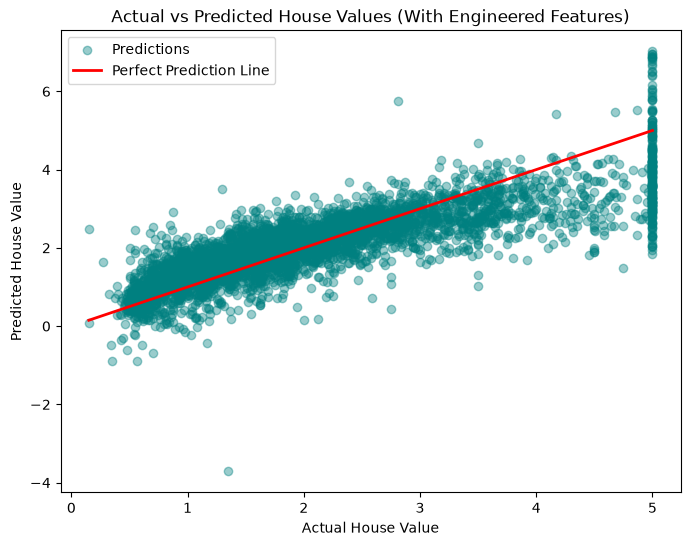

In [36]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, pred_after, alpha=0.4, color='teal', label='Predictions')

# Perfect prediction line (y = x)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         color='red', linewidth=2, label='Perfect Prediction Line')

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted House Values (With Engineered Features)")
plt.legend()
plt.show()

### Step 3: Feature Engineering
#### Create new, more meaningful features from existing ones


In [13]:
# Rooms per person in the house
df['RoomsPerHousehold'] = df['AveRooms'] / df['AveOccup']

# How many rooms are bedrooms (out of all rooms)
df['BedroomsPerRoom'] = df['AveBedrms'] / df['AveRooms']

# Number of houses/households in the area
df['PopulationPerHousehold'] = df['Population'] / df['AveOccup']

In [33]:
# Correlation of new features with house value
df[['RoomsPerHousehold', 'BedroomsPerRoom', 'PopulationPerHousehold', 'MedHouseVal']].corr()

,RoomsPerHousehold,BedroomsPerRoom,PopulationPerHousehold,MedHouseVal
RoomsPerHousehold,1.000000,-0.273808,-0.028473,0.209482
BedroomsPerRoom,-0.273808,1.000000,0.067022,-0.255624
PopulationPerHousehold,-0.028473,0.067022,1.000000,0.065843
MedHouseVal,0.209482,-0.255624,0.065843,1.000000


In [34]:
# Correlation of only new features with target variable
df[['RoomsPerHousehold', 'BedroomsPerRoom', 'PopulationPerHousehold']].corrwith(df['MedHouseVal'])

RoomsPerHousehold         0.209482
BedroomsPerRoom          -0.255624
PopulationPerHousehold    0.065843
dtype: float64

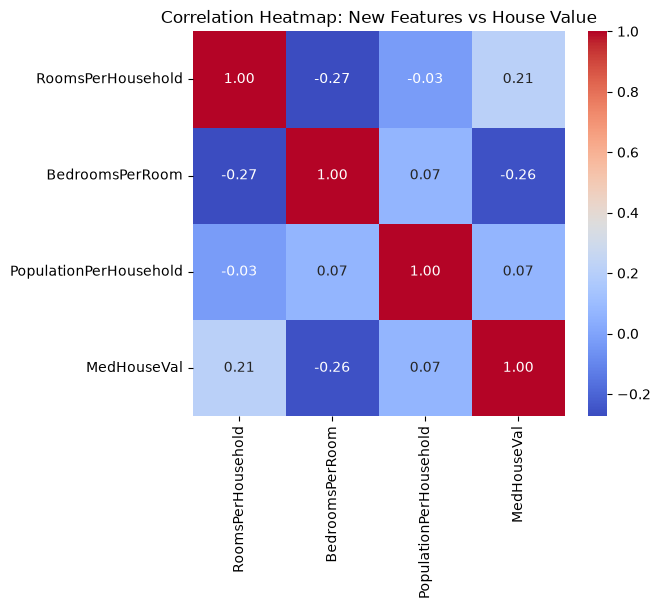

In [35]:
plt.figure(figsize=(6,5))
sns.heatmap(df[['RoomsPerHousehold', 'BedroomsPerRoom', 
                 'PopulationPerHousehold', 'MedHouseVal']].corr(), 
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap: New Features vs House Value")
plt.show()

In [ ]:
sns.scatterplot(x=df['RoomsPerHousehold'], y=df['MedHouseVal'], alpha=0.3) 
plt.plot

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,RoomsPerHousehold,BedroomsPerRoom,PopulationPerHousehold
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,2.732919,0.146591,126.0
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,2.956685,0.155797,1138.0
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,2.957661,0.129516,177.0
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,2.283154,0.184458,219.0
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,2.879646,0.172096,259.0


### Step 4: Train model WITH engineered features


In [23]:

X2 = df.drop(columns=['MedHouseVal'])
y2 = df['MedHouseVal']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=12
)

model_after = LinearRegression()
model_after.fit(X2_train, y2_train)
pred_after = model_after.predict(X2_test)
r2_after = r2_score(y2_test, pred_after)

print("R² WITH engineered features:", r2_after)

R² WITH engineered features: 0.6723786380612455


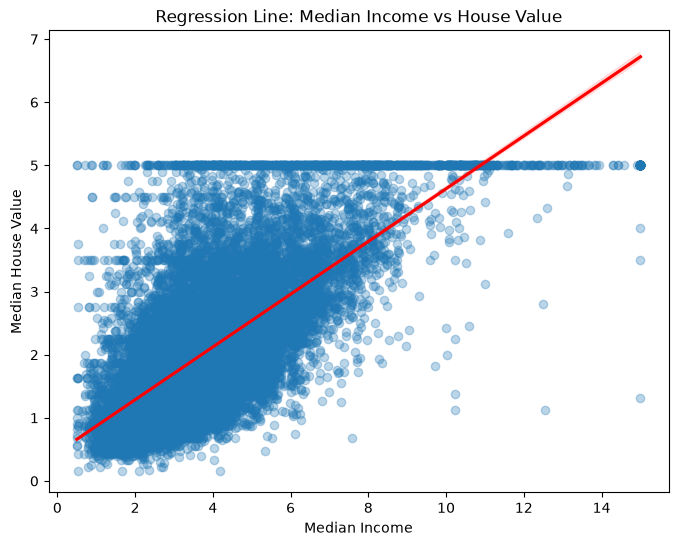

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.regplot(x=df['MedInc'], y=df['MedHouseVal'], 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title("Regression Line: Median Income vs House Value")
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.show()


### Step 5: Compare

In [24]:

print("\n--- Comparison ---")
print(f"Before Feature Engineering: R² = {r2_before:.4f}")
print(f"After Feature Engineering : R² = {r2_after:.4f}")


--- Comparison ---
Before Feature Engineering: R² = 0.6157
After Feature Engineering : R² = 0.6724


## Conclusion

In this activity, feature engineering was applied to the California Housing 
dataset to evaluate its impact on regression model performance.

Three new features were engineered from existing columns:
- **RoomsPerHousehold** (rooms available per person)
- **BedroomsPerRoom** (proportion of rooms that are bedrooms)
- **PopulationPerHousehold** (estimated number of households in the area)

These features were designed to convert raw counts into more meaningful 
ratios that better capture housing space, layout, and density — factors 
known to influence house prices.

A Linear Regression model was trained twice: once using only the original 
features, and once using the original features along with the three 
engineered features.

**Results:**
- R² score without engineered features: **[0.6157]**
- R² score with engineered features: **[0.6724]**

The R² score increased after 
adding the engineered features, indicating that these new features 
provided additional useful information to the model.

Overall, this activity demonstrates that feature engineering can help 
transform raw data into more informative representations, and that its 
effectiveness depends on how well the new features capture patterns not 
already present in the original data. Correlation analysis also confirmed 
that MedInc remains the strongest single predictor of house value, while 
the engineered features contributed smaller, supplementary signal.